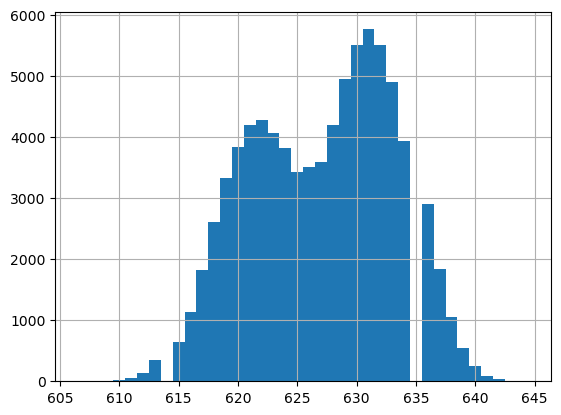

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("sensor_data_600.txt",delimiter=" ",
                   header=None, names=("date","time","ir","lidar"))

data["lidar"].hist(bins=max(data["lidar"])-min(data["lidar"]),align='left')
plt.show()

#sensor_data_600.txtからデータを読み込み、データのlidar列のヒストグラムを作成

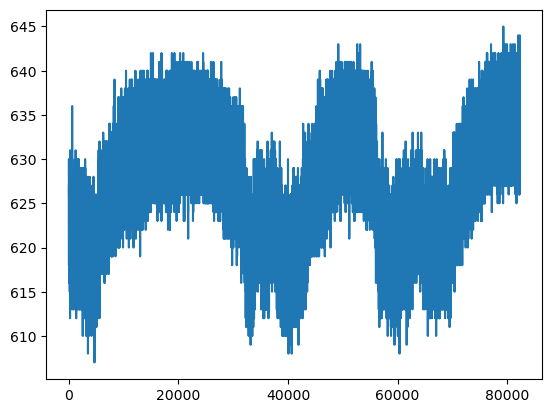

In [2]:
data.lidar.plot()      #data["lidar"].plotと同じ意味？　変数名によっては使えない
plt.show()             #今回のデータでは時系列順のセンサ値がグラフとして描画されている

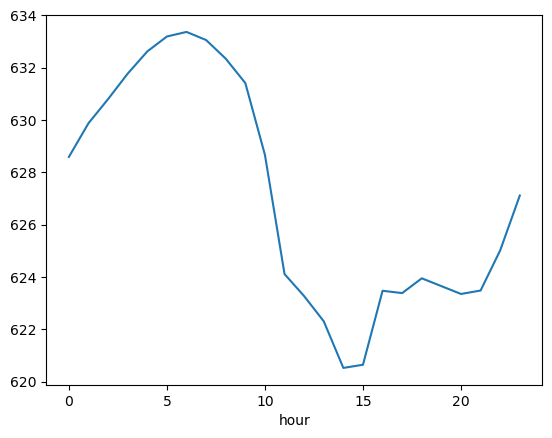

In [3]:
data["hour"]=[e//10000 for e in data.time]
#データフレームにhourという列を追加、hourには時分秒の６桁のデータを10000で割り、時間だけ残す
#//は小数点以下を切り捨てる割り算　　　　　　　　　　　　↑105320の場合、10となる
d = data.groupby("hour")
#hour列の値ごとに各レコードをグループ分けしたデータフレームdを作成  data("hour":"lidar")
d.lidar.mean().plot()        #dの時間ごとのlidarのセンサ値の平均値を求め、プロット
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

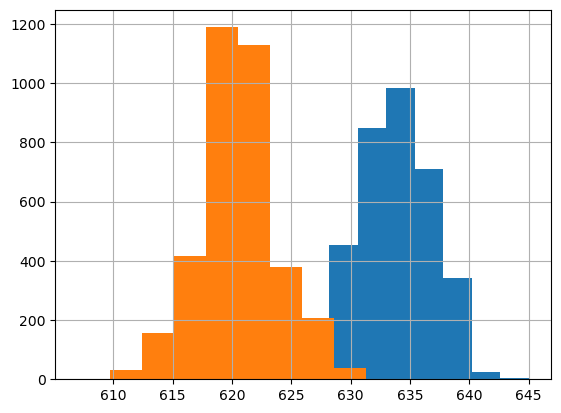

In [4]:
d.lidar.get_group(6).hist()      #dのグループ(6)にあるセンサ値のヒストグラム作成
d.lidar.get_group(14).hist()     #14時のセンサ値のヒストグラム
plt.show

In [5]:
each_hour = {i:d.lidar.get_group(i).value_counts().sort_index() for i in range(24)}
#時間ごとにデータフレーム作成　get_groupでグループ(i)内のセンサ値を獲得.グループ(i)の同じ値をカウント.値を並び替え
#辞書内包表記i:d.lidar.get_group(i)   {i:センサ値}という辞書を作る　　iが辞書のキーとなる
#24個の辞書型のデータフレームがeach_hourの中に作られた
freqs = pd.concat(each_hour, axis=1)     #24個のデータフレームをconcatで１個に連結させる
freqs = freqs.fillna(0)                  #欠損値(NaN)を０で埋める　　fillna()は欠損値(NaN)を()内の値で埋めるメソッド
probs = freqs/len(data)                  #頻度を全体の大きさで割り確率を求める

probs   #同時確率P(z,t)を出力

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
lidar,,,,,,,,,,,,,,,,,,,,,
618,0.000036,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.004326,0.003791,0.001106,0.001750,0.001774,0.002272,0.002916,0.003135,0.001908,0.000401
619,0.000219,0.000049,0.000012,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.004982,0.004301,0.001810,0.002697,0.002309,0.003341,0.003657,0.003475,0.002539,0.000729
620,0.000389,0.000073,0.000036,0.000012,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.005140,0.005371,0.002892,0.003013,0.002710,0.004119,0.003900,0.003621,0.002685,0.001021
621,0.000559,0.000158,0.000036,0.000000,0.000000,0.000012,0.000012,0.000000,0.000000,0.000000,...,0.004921,0.005650,0.003912,0.003706,0.003196,0.004435,0.003512,0.003985,0.003451,0.001895
622,0.001033,0.000219,0.000085,0.000024,0.000000,0.000000,0.000000,0.000000,0.000000,0.000061,...,0.004799,0.005030,0.005407,0.004411,0.004180,0.003755,0.003062,0.003038,0.003475,0.002333
623,0.001604,0.000535,0.000231,0.000036,0.000049,0.000012,0.000012,0.000024,0.000012,0.000036,...,0.003985,0.003888,0.006185,0.004471,0.003864,0.002710,0.002357,0.002345,0.003268,0.003268
624,0.002175,0.000972,0.000547,0.000194,0.000061,0.000049,0.000024,0.000049,0.000097,0.000134,...,0.002782,0.003171,0.005553,0.004338,0.004301,0.002539,0.001835,0.001944,0.002685,0.003475
625,0.003062,0.001823,0.000911,0.000462,0.000146,0.000049,0.000085,0.000109,0.000292,0.000413,...,0.001823,0.002248,0.005152,0.003937,0.003669,0.001847,0.001106,0.001349,0.002369,0.003062
626,0.003742,0.002685,0.001507,0.001094,0.000462,0.000243,0.000219,0.000377,0.000559,0.000668,...,0.001349,0.001434,0.003755,0.003402,0.003524,0.001944,0.001252,0.001057,0.002066,0.003548


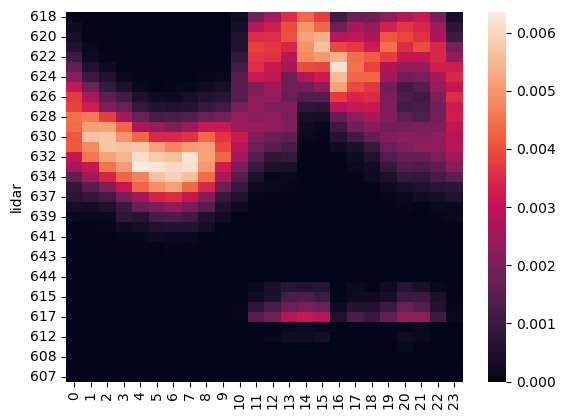

In [6]:
import seaborn as sns

sns.heatmap(probs)     #確率が大きいほど明るく表示されるヒートマップ
plt.show()

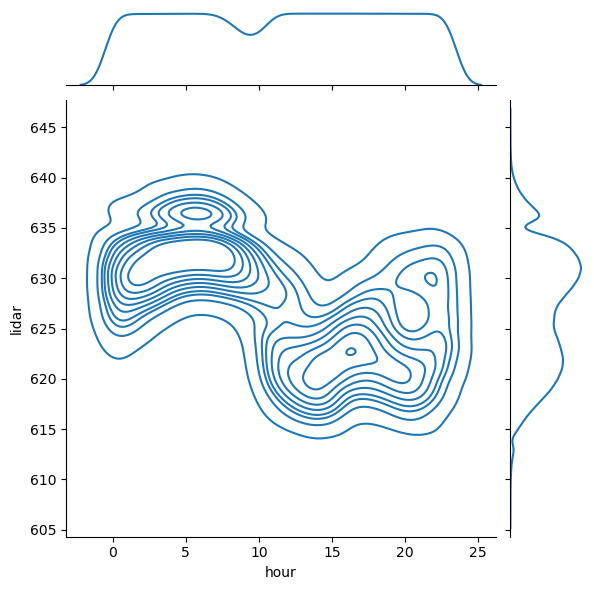

In [7]:
sns.jointplot(data,x="hour",y="lidar",kind="kde")
#seabornのメソッド　dataを使ってヒストグラムを描画   kindでグラフを指定　kdeはカーネル密度推定
#カーネル密度推定を行うことでグラフが平滑化され、ゼロがゼロでなくなるので注意
plt.show()

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,0.043013,0.042916,0.042879,0.042916,0.042964,0.043037,0.043061,0.043001,0.038712,0.028651,...,0.043183,0.043122,0.043061,0.043122,0.043049,0.043086,0.043159,0.042976,0.043049,0.043037


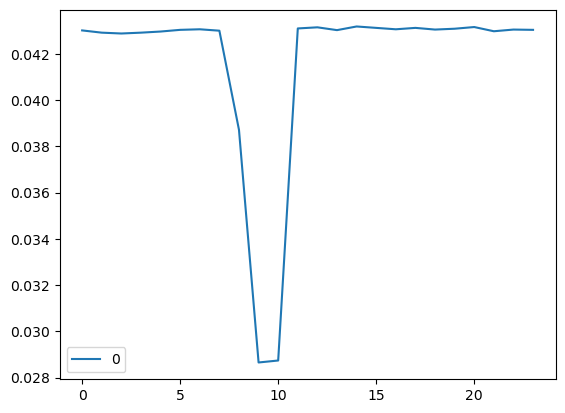

In [8]:
p_t = pd.DataFrame(probs.sum())  #各列を合計
p_t.plot()  #同時確率P(z,t)の周辺確率P(t)
p_t.transpose()  #表を横並びに出力

lidar,607,608,609,610,611,612,613,615,616,617,...,636,637,638,639,640,641,642,643,644,645
0,0.000012,0.000049,0.000061,0.000328,0.00068,0.00158,0.004241,0.007752,0.013852,0.022053,...,0.03537,0.02226,0.012819,0.006671,0.002989,0.000996,0.000401,0.000109,0.000024,0.000012


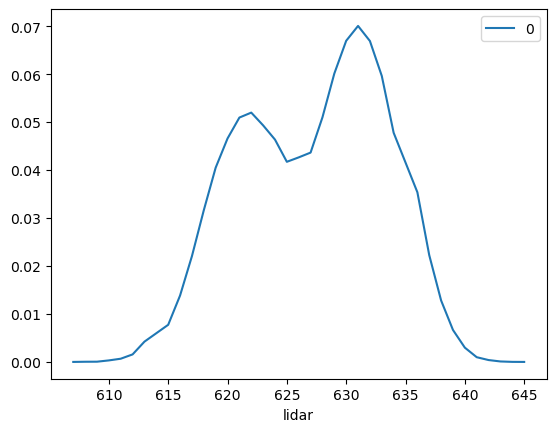

In [9]:
p_z = pd.DataFrame(probs.transpose().sum()).sort_values("lidar")  #行と列を転置して各列を合計
p_z.plot()    #同時確率P(z,t)の周辺確率P(z)
p_z.transpose()  #表を横並びに出力

In [10]:
p_t.sum()

0    1.0
dtype: float64

In [11]:
p_z.sum()

0    1.0
dtype: float64

In [12]:
cond_z_t = (probs/p_t[0]).sort_values("lidar")
#列（時間）ごとに周辺確率P(t)で割ることで条件付き確率P(z|t)　　　p_t[0]は0という名前の列を指定
cond_z_t

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
lidar,,,,,,,,,,,,,,,,,,,,,
607,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000281,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
608,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000281,0.000000,0.000000,0.000000,0.000000,0.000000,0.000282,0.000283,0.000000,0.000000
609,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000564,0.000000,0.000000,0.000000,0.000000,0.000000,0.000283,0.000282,0.000000
610,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000844,0.001127,0.000000,0.000000,0.000282,0.000282,0.003097,0.000000,0.000000,0.000000
611,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.003376,0.002818,0.000000,0.000000,0.000000,0.000564,0.001689,0.003393,0.001129,0.000000
612,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.005065,0.007326,0.000000,0.000845,0.000847,0.001410,0.005912,0.004524,0.000564,0.000282
613,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.014350,0.014934,0.000564,0.004227,0.001411,0.005076,0.015766,0.010178,0.002540,0.000565
615,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.030107,0.024232,0.000564,0.004790,0.006209,0.008742,0.022804,0.023749,0.011008,0.001129
616,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.045301,0.041984,0.005079,0.013807,0.013830,0.023689,0.039977,0.032513,0.013830,0.001976


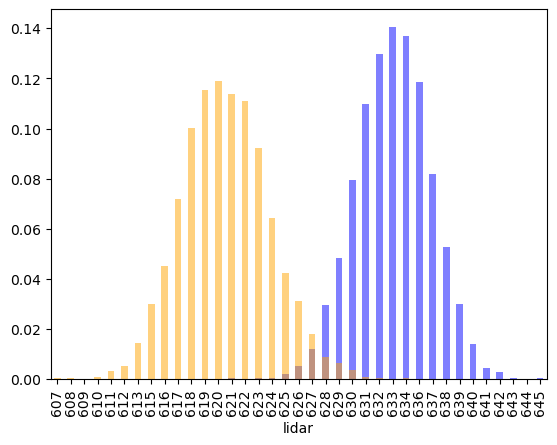

In [15]:
(cond_z_t[6]).plot.bar(color="blue",alpha=0.5)
(cond_z_t[14]).plot.bar(color="orange",alpha=0.5)
#6時と14時のlidarのセンサ値の確率分布P(z|t=6),P(z|t=14)
plt.show()

In [19]:
cond_t_z=probs.transpose()/probs.transpose().sum()  #行と列を入れ替えて同様の計算を行いP(t|z)を作る

print(f"""
P(z=630)={p_z[0][630]}    
P(t=13)={p_t[0][13]}
P(t=13|z=630)={cond_t_z[630][13]}

Bayes P(z=630|t=13)={cond_t_z[630][13]*p_z[0][630]/p_t[0][13]}
answer P(z=630|t=13)={cond_z_t[13][630]}
""")

#センサ値が630になる確率
#時間が13時である確率
#センサ値が630のとき時間が13時になる同時確率
#ベイズの定理P(z|t)={P(t|z)*P(z)}/P(t)より時間が13時の時にセンサ値が630になる同時確率
#時間が13時の時にセンサ値が630になる同時確率


P(z=630)=0.06694936878045224    
P(t=13)=0.043024993620976656
P(t=13|z=630)=0.023230490018148822

Bayes P(z=630|t=13)=0.036147980796385204
answer P(z=630|t=13)=0.036147980796385204



In [23]:
def bayes_estimation(sensor_value,current_estimation):
    new_estimation = []
    for i in range(24):
        new_estimation.append(cond_z_t[i][sensor_value]*current_estimation[i])
        #↑のリストにP(z|t)*P(t)を計算して加える　　P(t|z)=ηP(z|t)*P(t)で使うため
        #確率分布の積分が1となる定数がηなので1.0=η*sum(new_estimation)
    return new_estimation/sum(new_estimation)    #正規化　　1/sum(new_estimation)がη

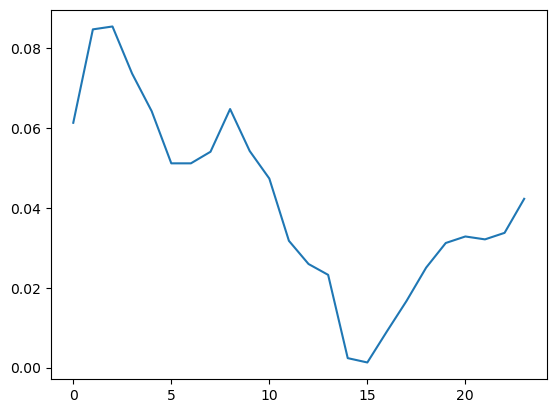

In [24]:
estimation = bayes_estimation(630,p_t[0])
#センサ値が630の時の時間を推定する　　出力はP(t|z)
plt.plot(estimation)

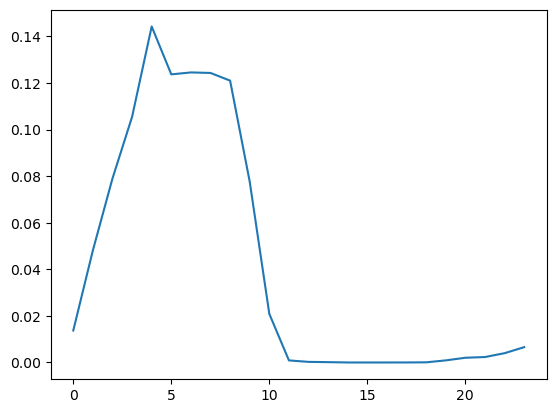

In [25]:
values_5 = [630,632,636] #5時台に得られたセンサ値

estimation = p_t[0]
for v in values_5:
    estimation = bayes_estimation(v,estimation)

plt.plot(estimation)
#3つのセンサ値が得られた時間を推定　P(t|z=630,632,636)

5時周辺の確率が0.1を超えており大雑把に推定できている

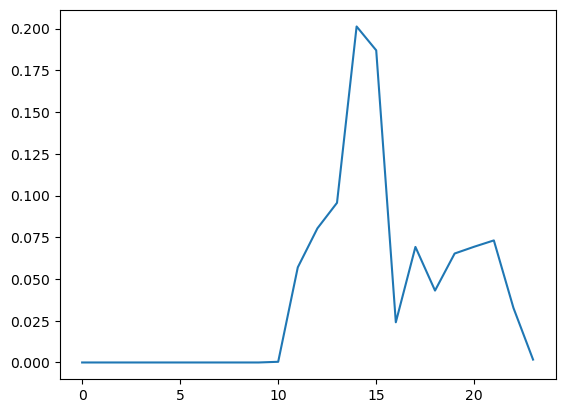

In [30]:
values_11 = [617,624,619] #11時台に得られたセンサ値

estimation = p_t[0]
for v in values_11:
    estimation = bayes_estimation(v,estimation)

plt.plot(estimation)

In [ ]:
13～15